## Setup

In [ ]:
import sys
import os
from pathlib import Path

sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("image-data.ipynb"), '../..')))

from image_data.experiment import Experiment

## Generate Mask

Using cached weights: /Volumes/T7/Image-Analysis/Ir-Complex-Reduction/model/best.pth
Tiling: 108 tiles (256x256, overlap=32)


Inference:  10%|█         | 11/108 [00:45<03:53,  2.41s/tile]W0513 16:24:44.834000 3448 site-packages/torch/_inductor/utils.py:1679] [0/1] Not enough SMs to use max_autotune_gemm mode
W0513 16:25:05.461000 3448 site-packages/torch/_dynamo/convert_frame.py:2035] WON'T CONVERT forward /Volumes/T7/Image-Analysis/image-env/lib/python3.14/site-packages/maskgen/model.py line 189 
W0513 16:25:05.461000 3448 site-packages/torch/_dynamo/convert_frame.py:2035] due to: 
W0513 16:25:05.461000 3448 site-packages/torch/_dynamo/convert_frame.py:2035] Traceback (most recent call last):
W0513 16:25:05.461000 3448 site-packages/torch/_dynamo/convert_frame.py:2035]   File "/Volumes/T7/Image-Analysis/image-env/lib/python3.14/site-packages/torch/_dynamo/convert_frame.py", line 1945, in __call__
W0513 16:25:05.461000 3448 site-packages/torch/_dynamo/convert_frame.py:2035]     result = self._inner_convert(
W0513 16:25:05.461000 3448 site-packages/torch/_dynamo/convert_frame.py:2035]         frame, cache_entr

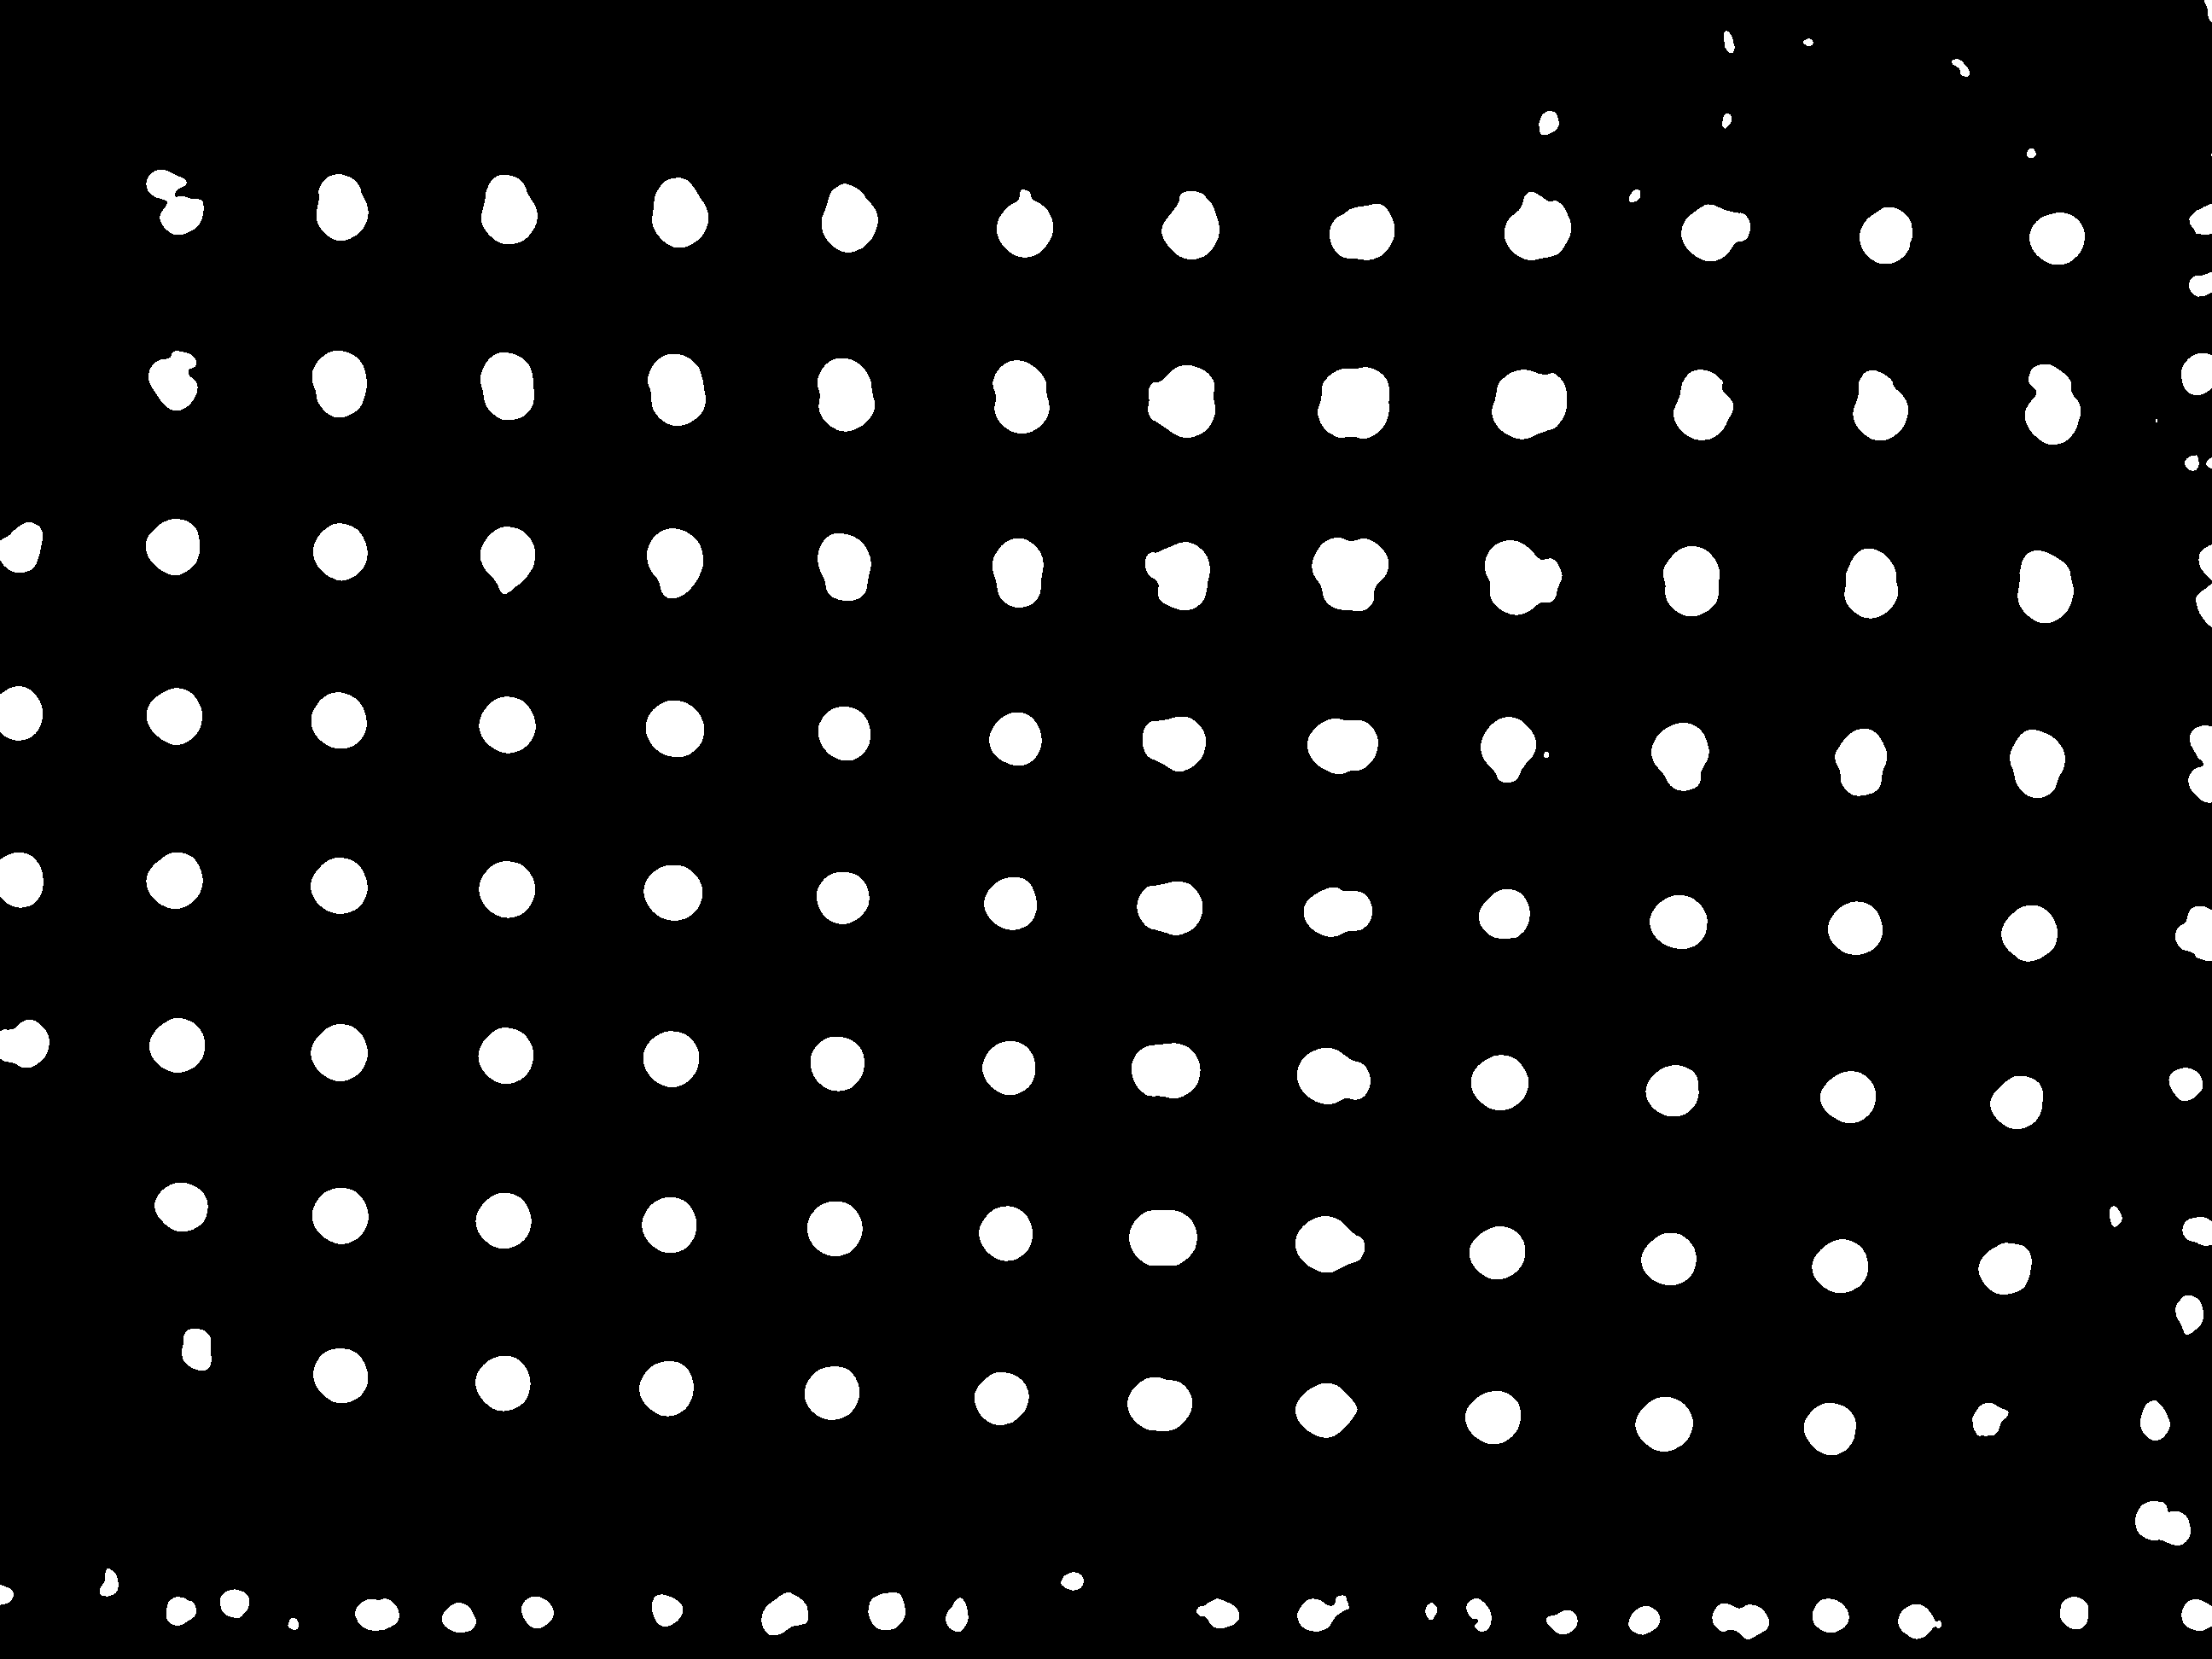

In [10]:
from maskgen import MaskGenerator, download_weights

gen = MaskGenerator(download_weights(cache_dir = "/Volumes/T7/Image-Analysis/Ir-Complex-Reduction/model"))
gen.generate_and_save(
    "/Volumes/T7/Image-Analysis/Ir-Complex-Reduction/05-11-26-Vaporeon/input/images/bottom/IT-0_y26m05d11H13M54S03.png",
    "/Volumes/T7/Image-Analysis/Ir-Complex-Reduction/05-11-26-Vaporeon/input/masks/bottom/mask.png",
    strategy={"name": "tile", "tile_size": 256, "overlap": 32},
)

## Remove Unnecessary Files

In [2]:
start_dir = os.getcwd()

def removeDot():
    filepath = "/Volumes/T7/Image-Analysis/Ir-Complex-Reduction/05-11-26-Vaporeon"
    os.chdir(filepath)
    removeDotHelper(filepath)

def removeDotHelper(filepath):
    
    !rm -r .*
    for file in os.listdir():

        if os.path.isdir(os.path.join(filepath, file)):
            newFilePath = filepath + '/' + file
            os.chdir(newFilePath)
            removeDotHelper(newFilePath)
            
    return

removeDot()
os.chdir(start_dir)

zsh:1: no matches found: .*
zsh:1: no matches found: .*
zsh:1: no matches found: .*
zsh:1: no matches found: .*
zsh:1: no matches found: .*
zsh:1: no matches found: .*


## User Options

In [3]:
# Read the user parameters from the config file, explore the input directory
# to find the input images/masks, and create the output directory structure.
config_file_name = "image-data-vars.yaml"      # Replace with yaml file name
experiment = Experiment(config_file_name)
user_parameters = experiment.get_user_parameters()

/Volumes/T7/Image-Analysis/Ir-Complex-Reduction/05-11-26-Vaporeon
1


## Mask Creation and Validation

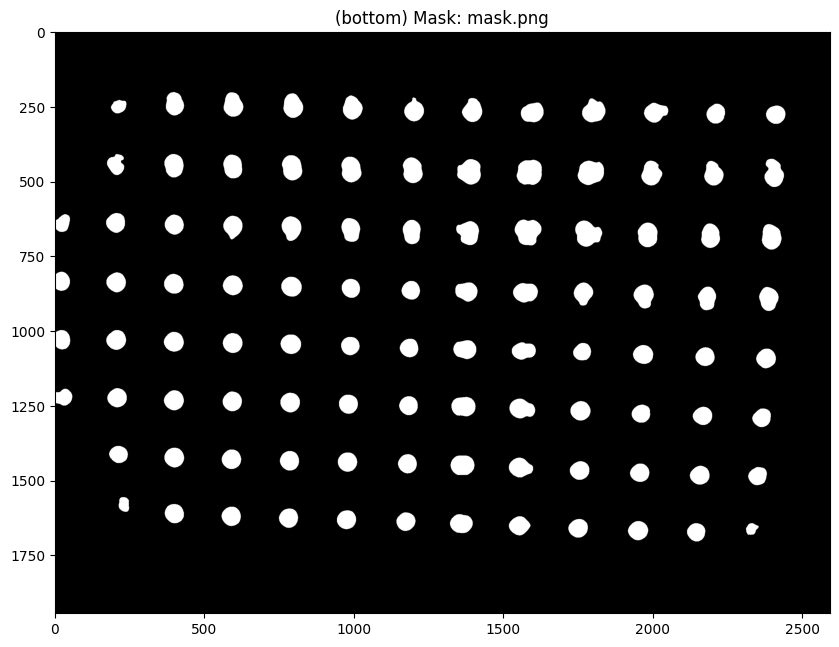

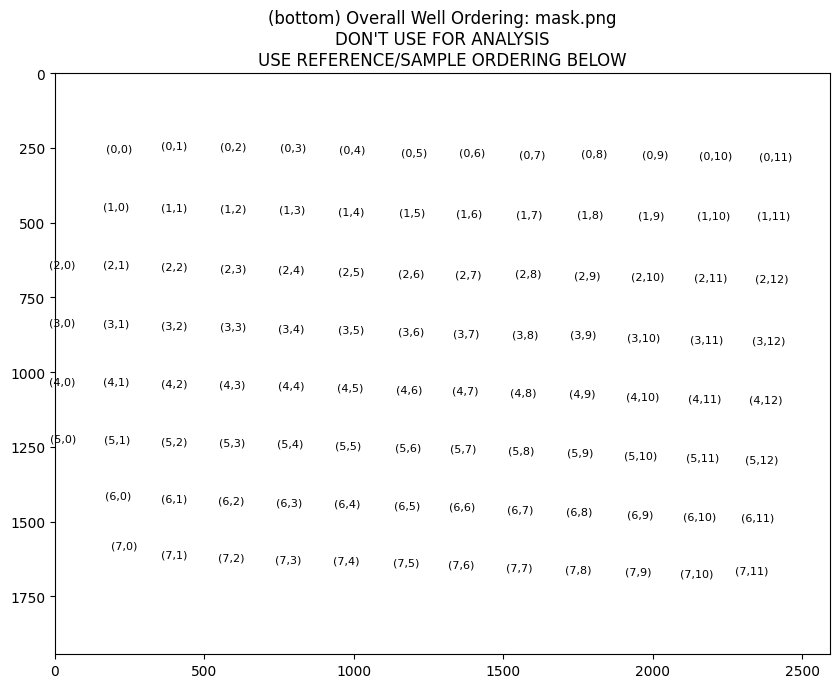

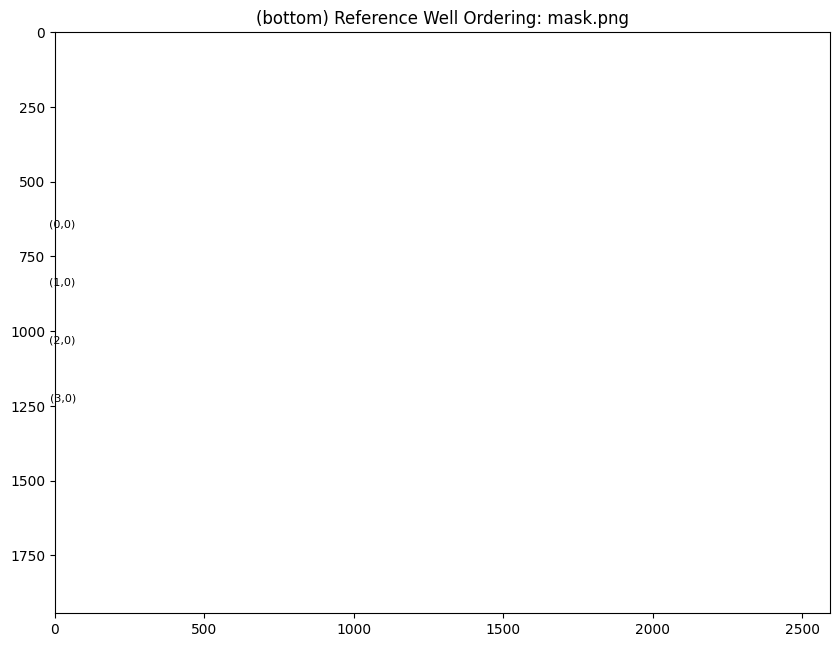

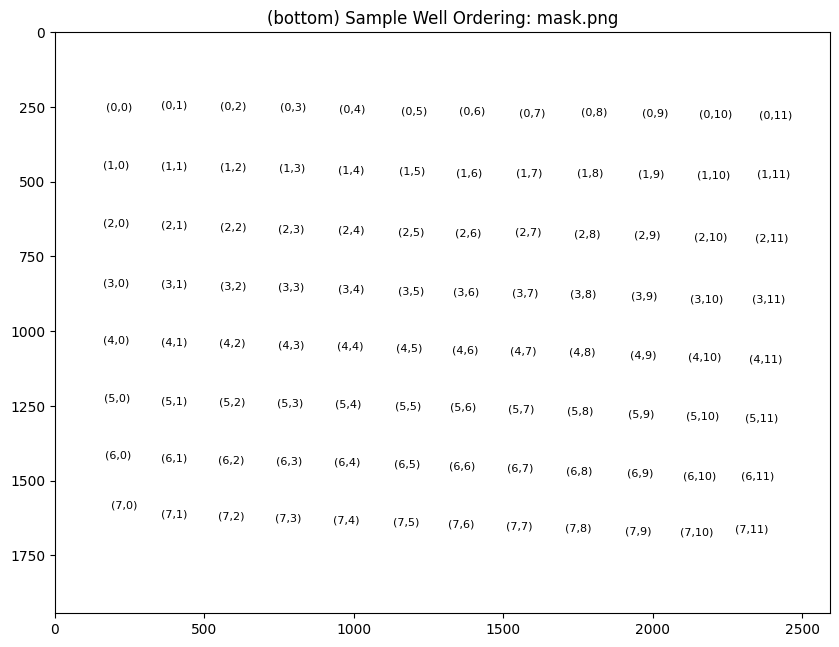

In [4]:
# Load and process the masks (for analysis) or mask datasets (for calibration).
experiment.process_masks_or_mask_datasets()

## Load Image Datasets

In Process:  /Volumes/T7/Image-Analysis/Ir-Complex-Reduction/05-11-26-Vaporeon/input/images/bottom


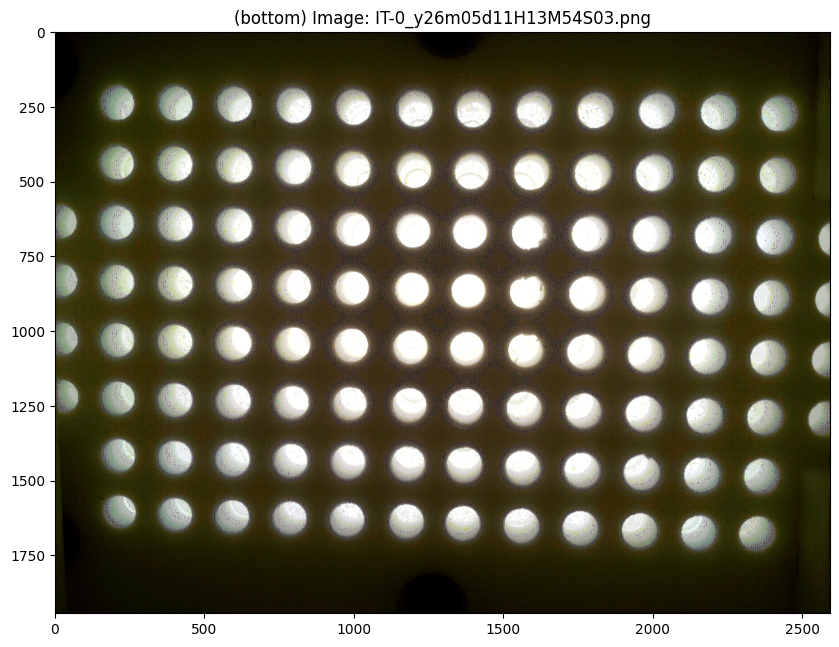

In [5]:
# Load the image datasets.
experiment.load_image_datasets()

## Movie Generation

In [6]:
# Generate the movies.
experiment.generate_movies()

## Image Intensity Processing

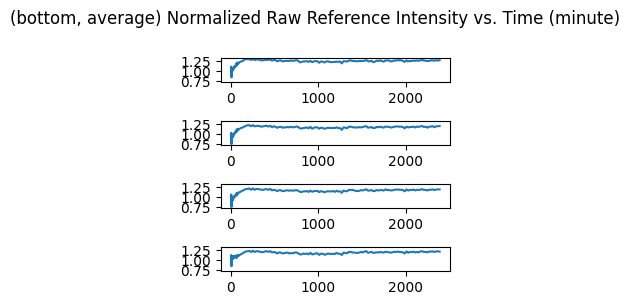

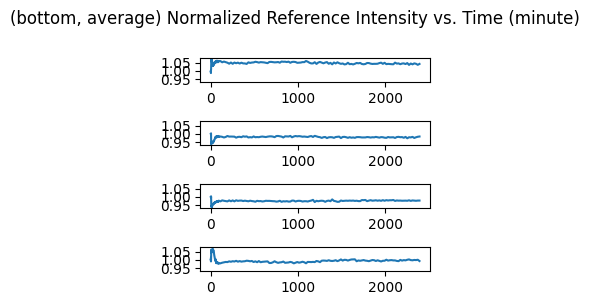

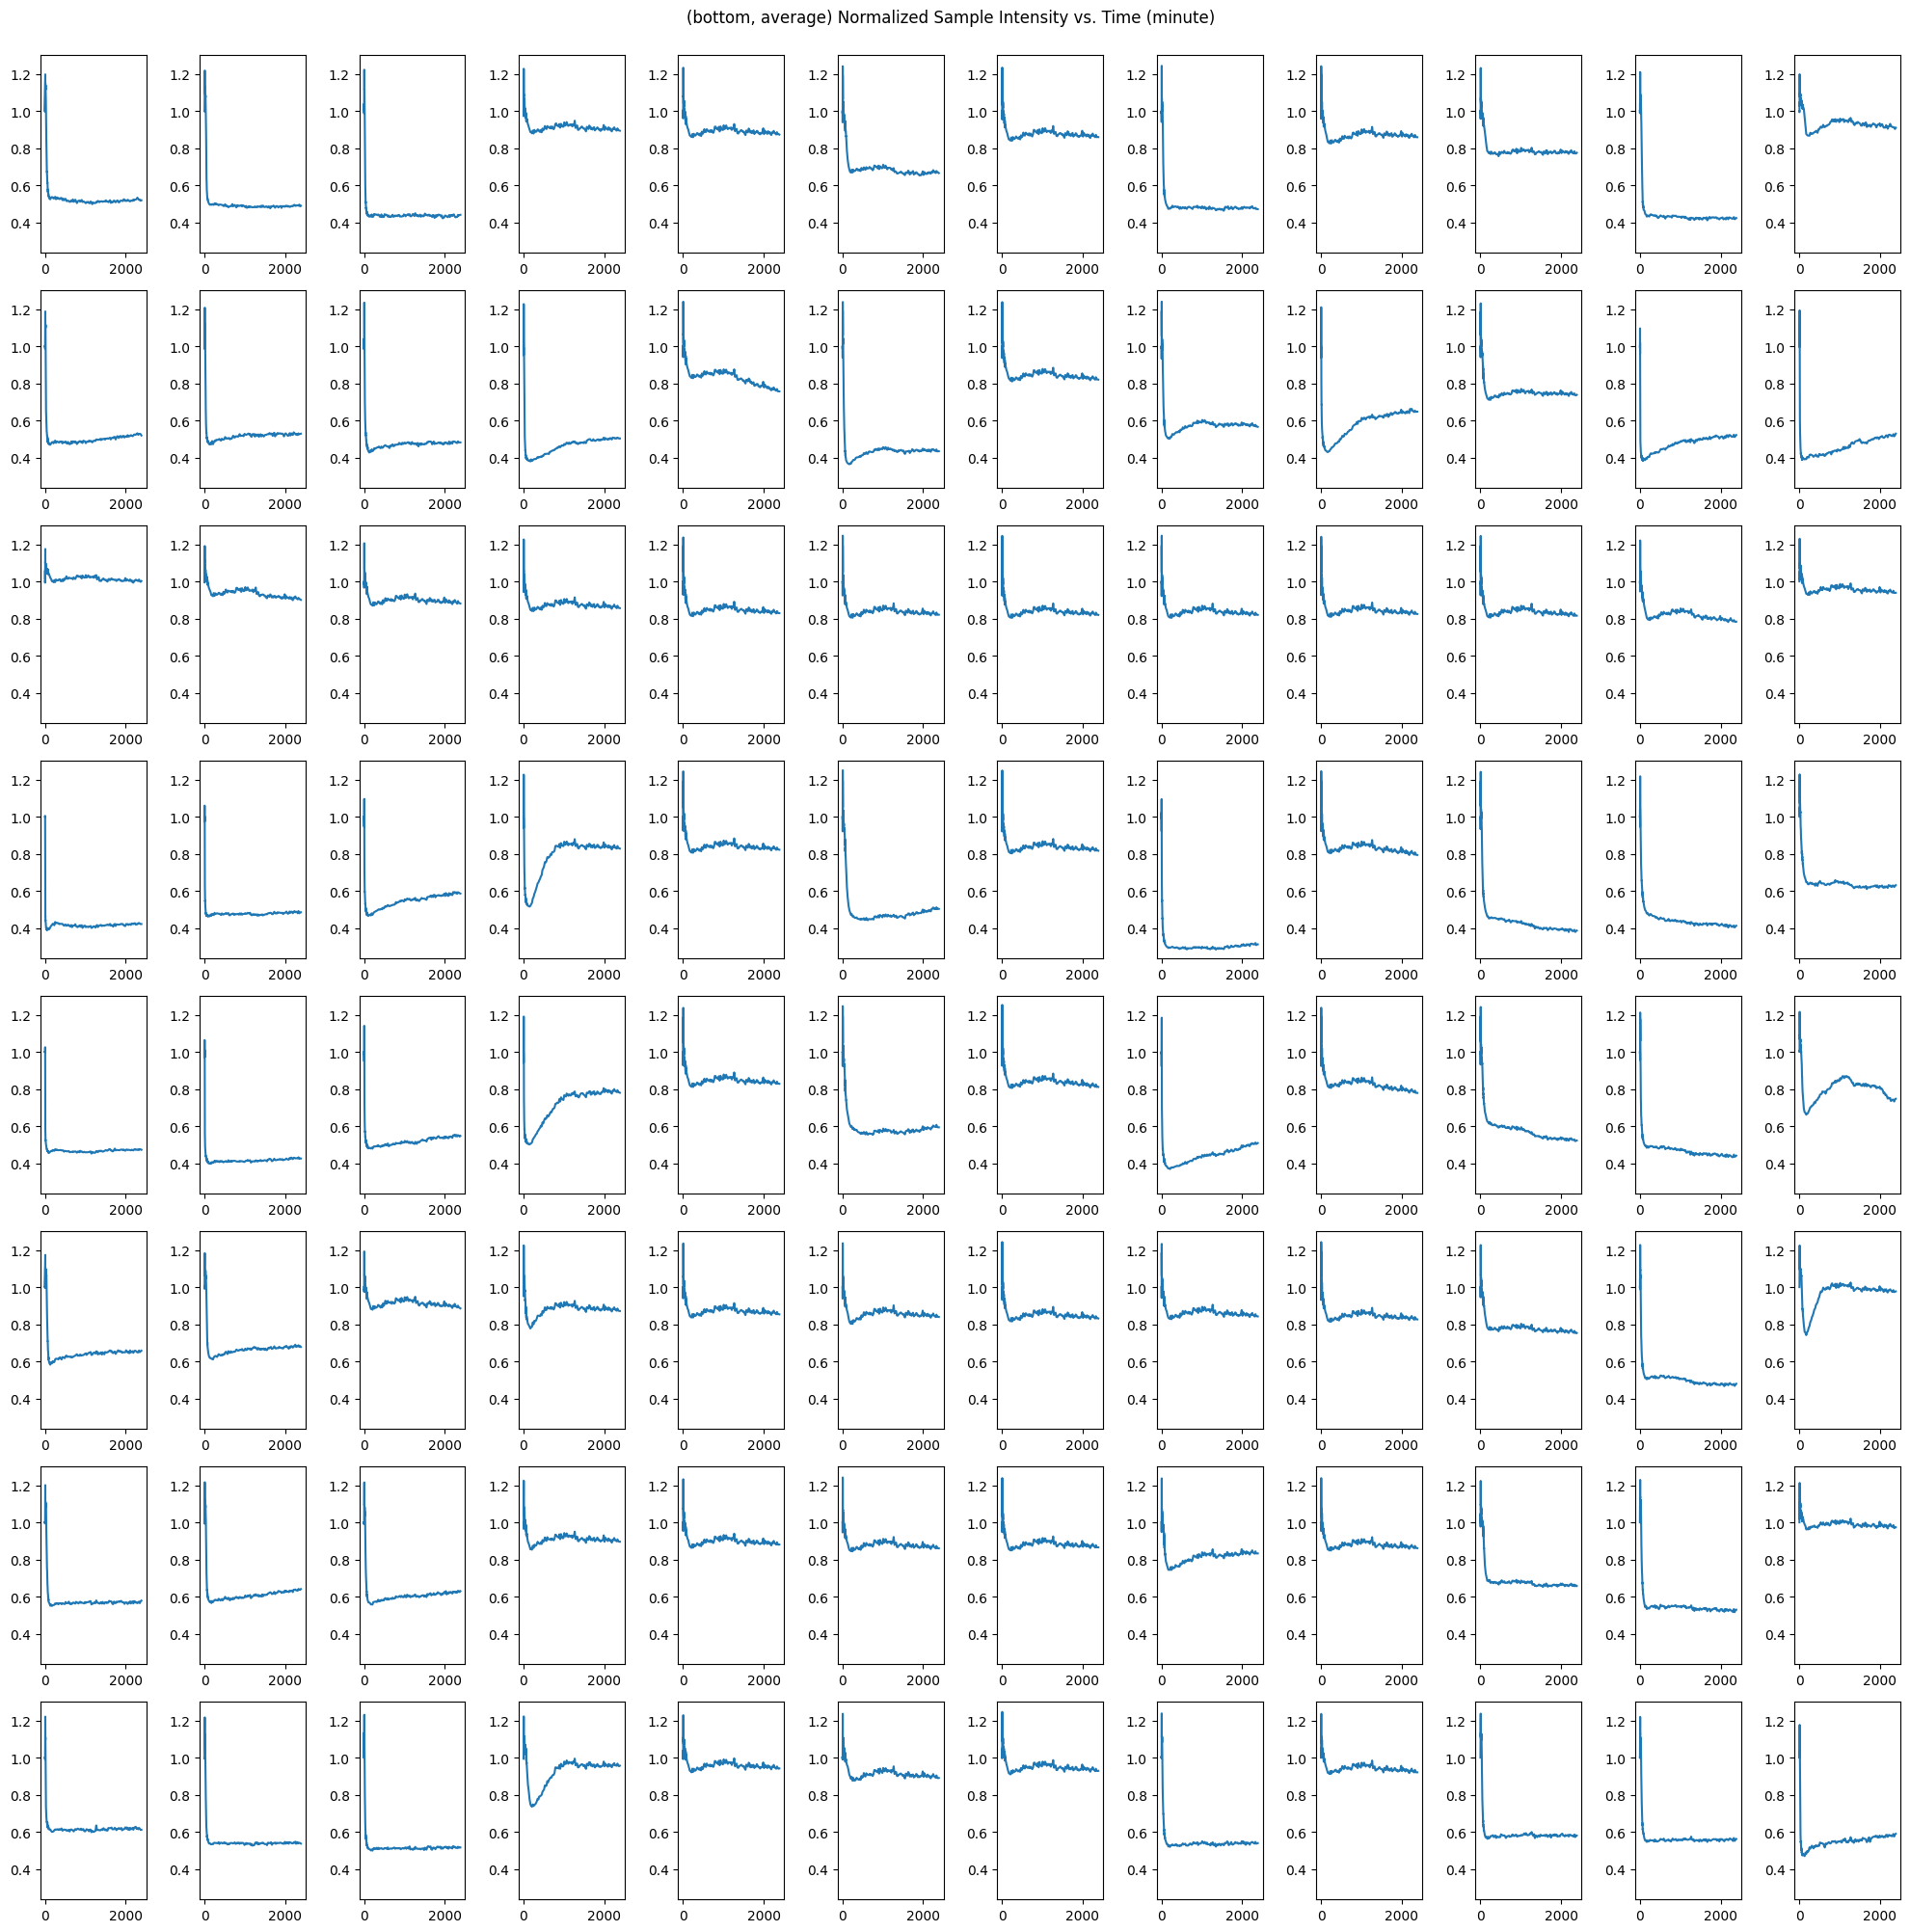

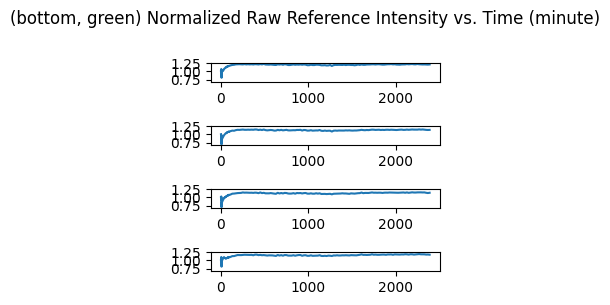

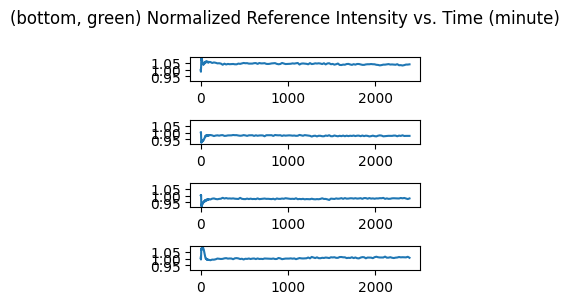

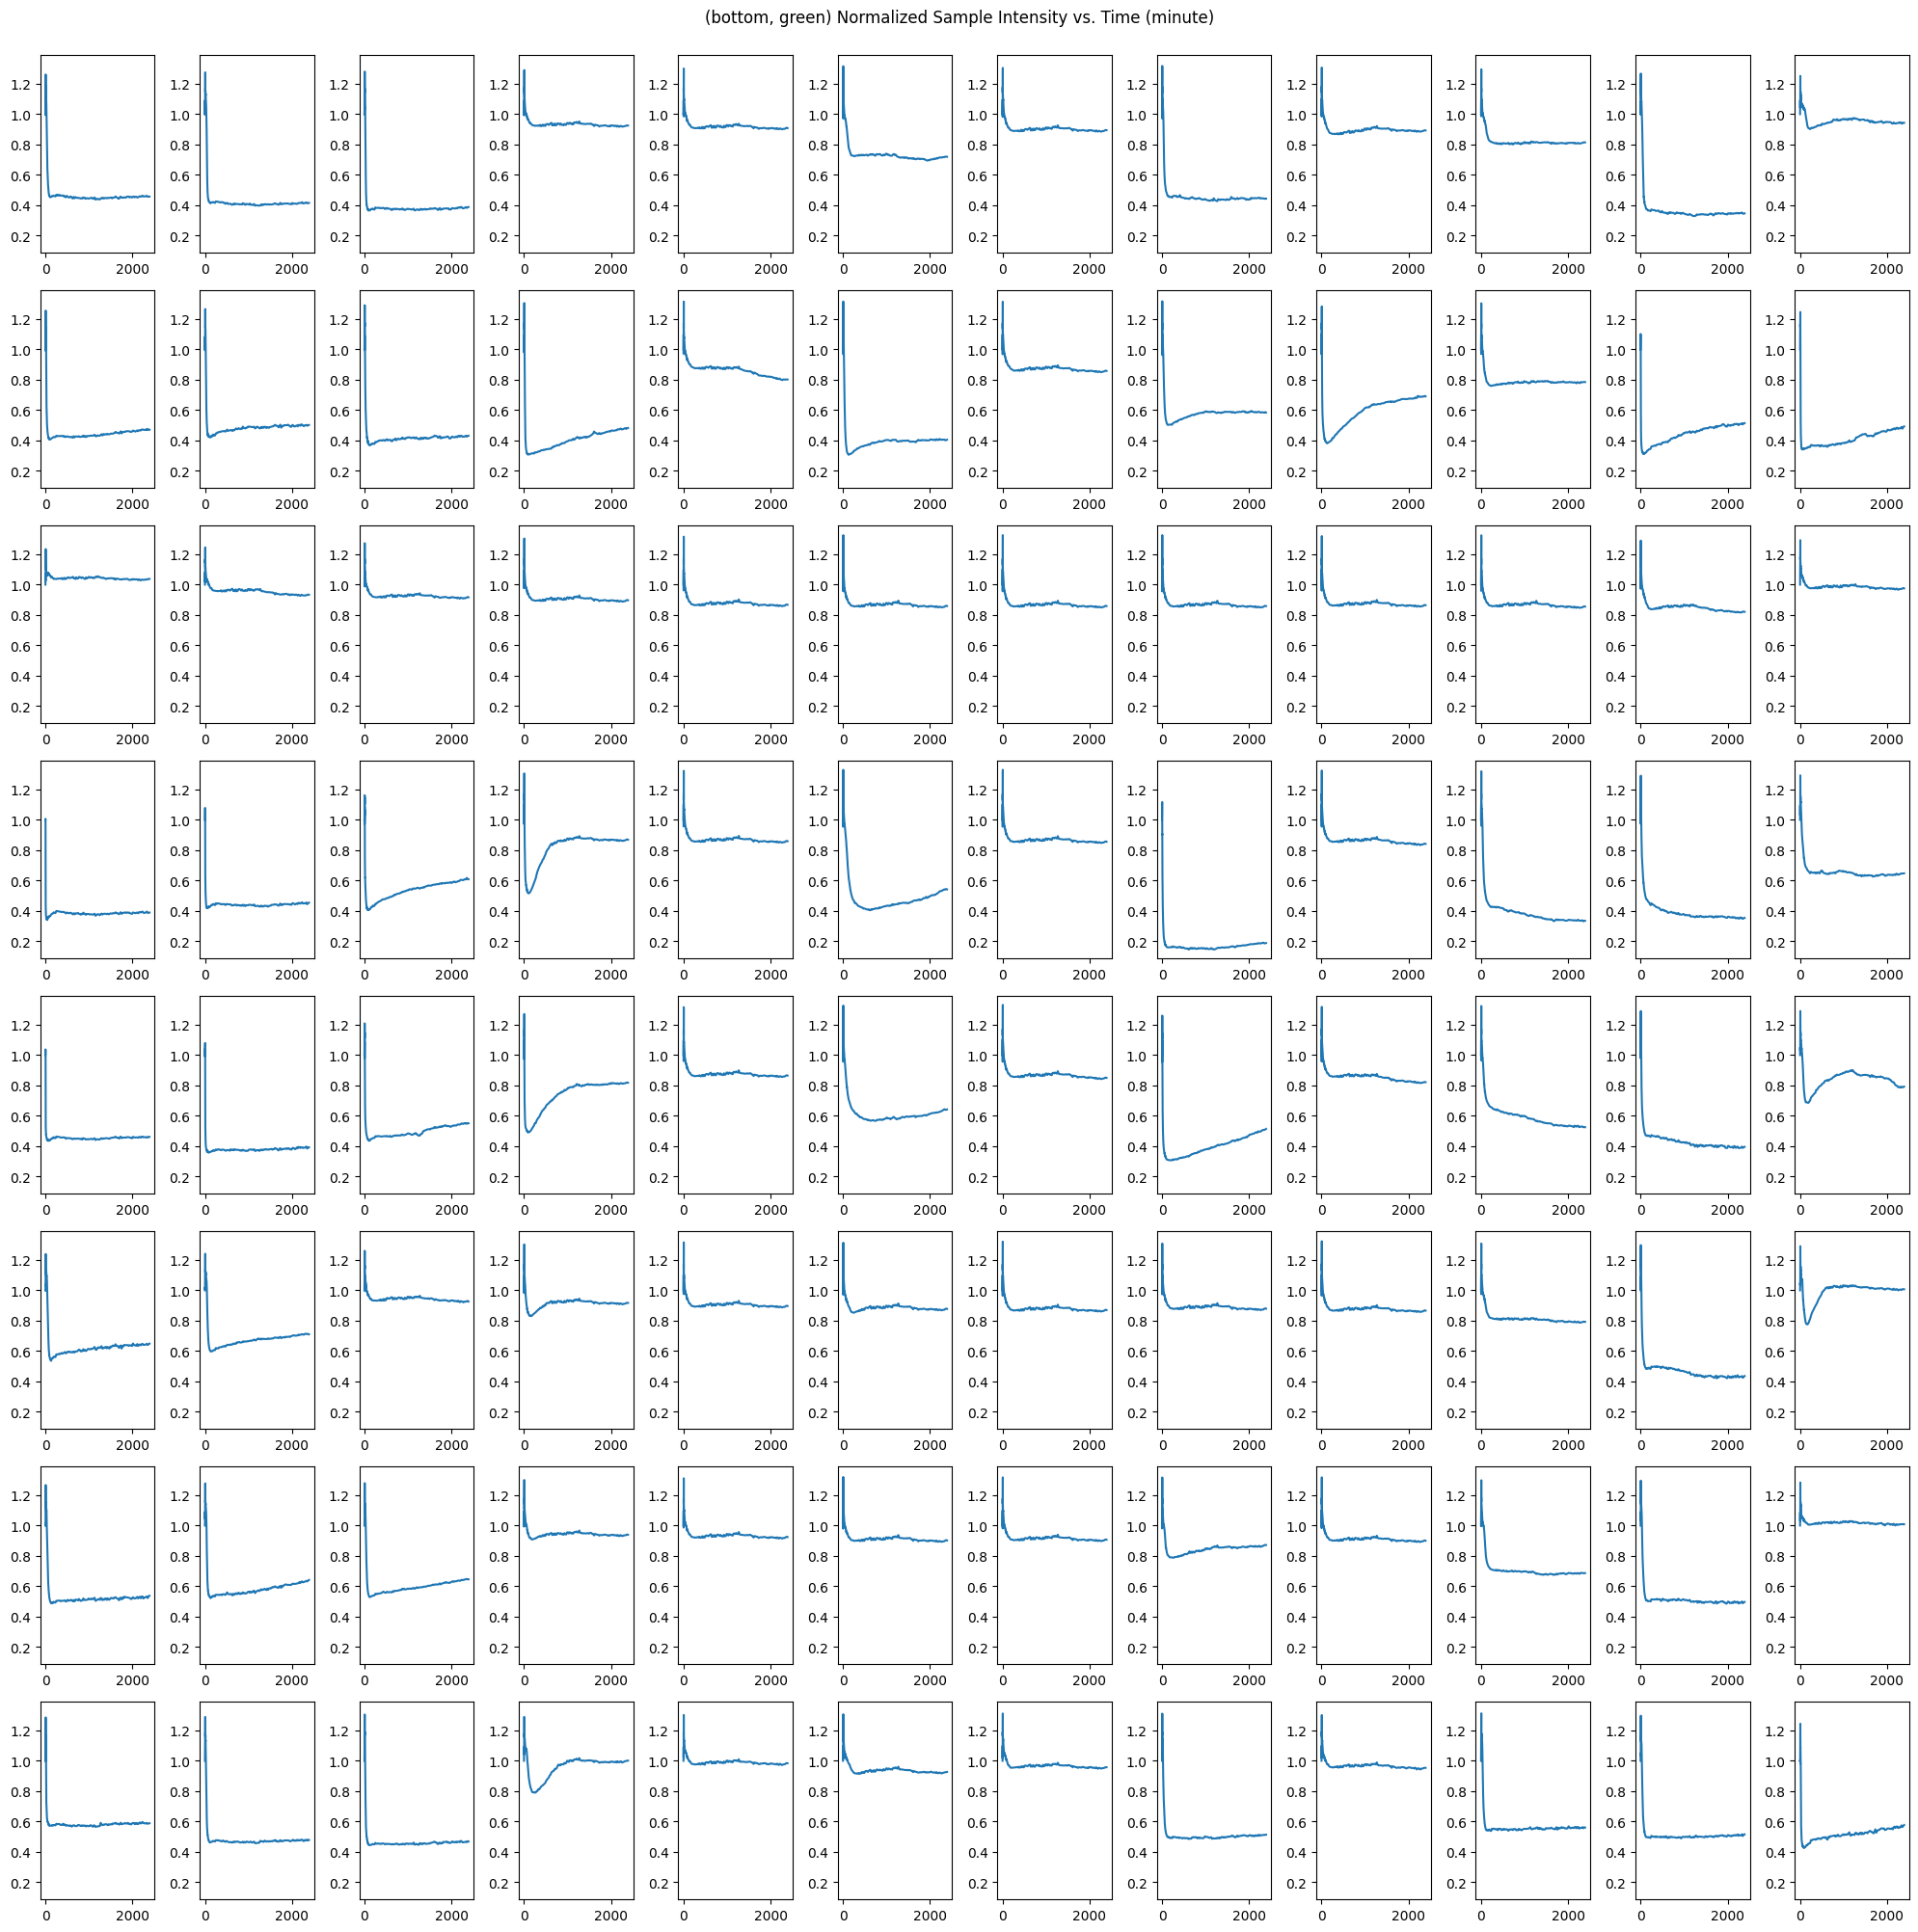

In [7]:
# Process the intensities.
experiment.process_image_datasets_intensity()

## Post-Processing

In [8]:
# Compute the requested data from the intensities.
experiment.post_process_intensity_datasets()

## Display Post-Processed Results

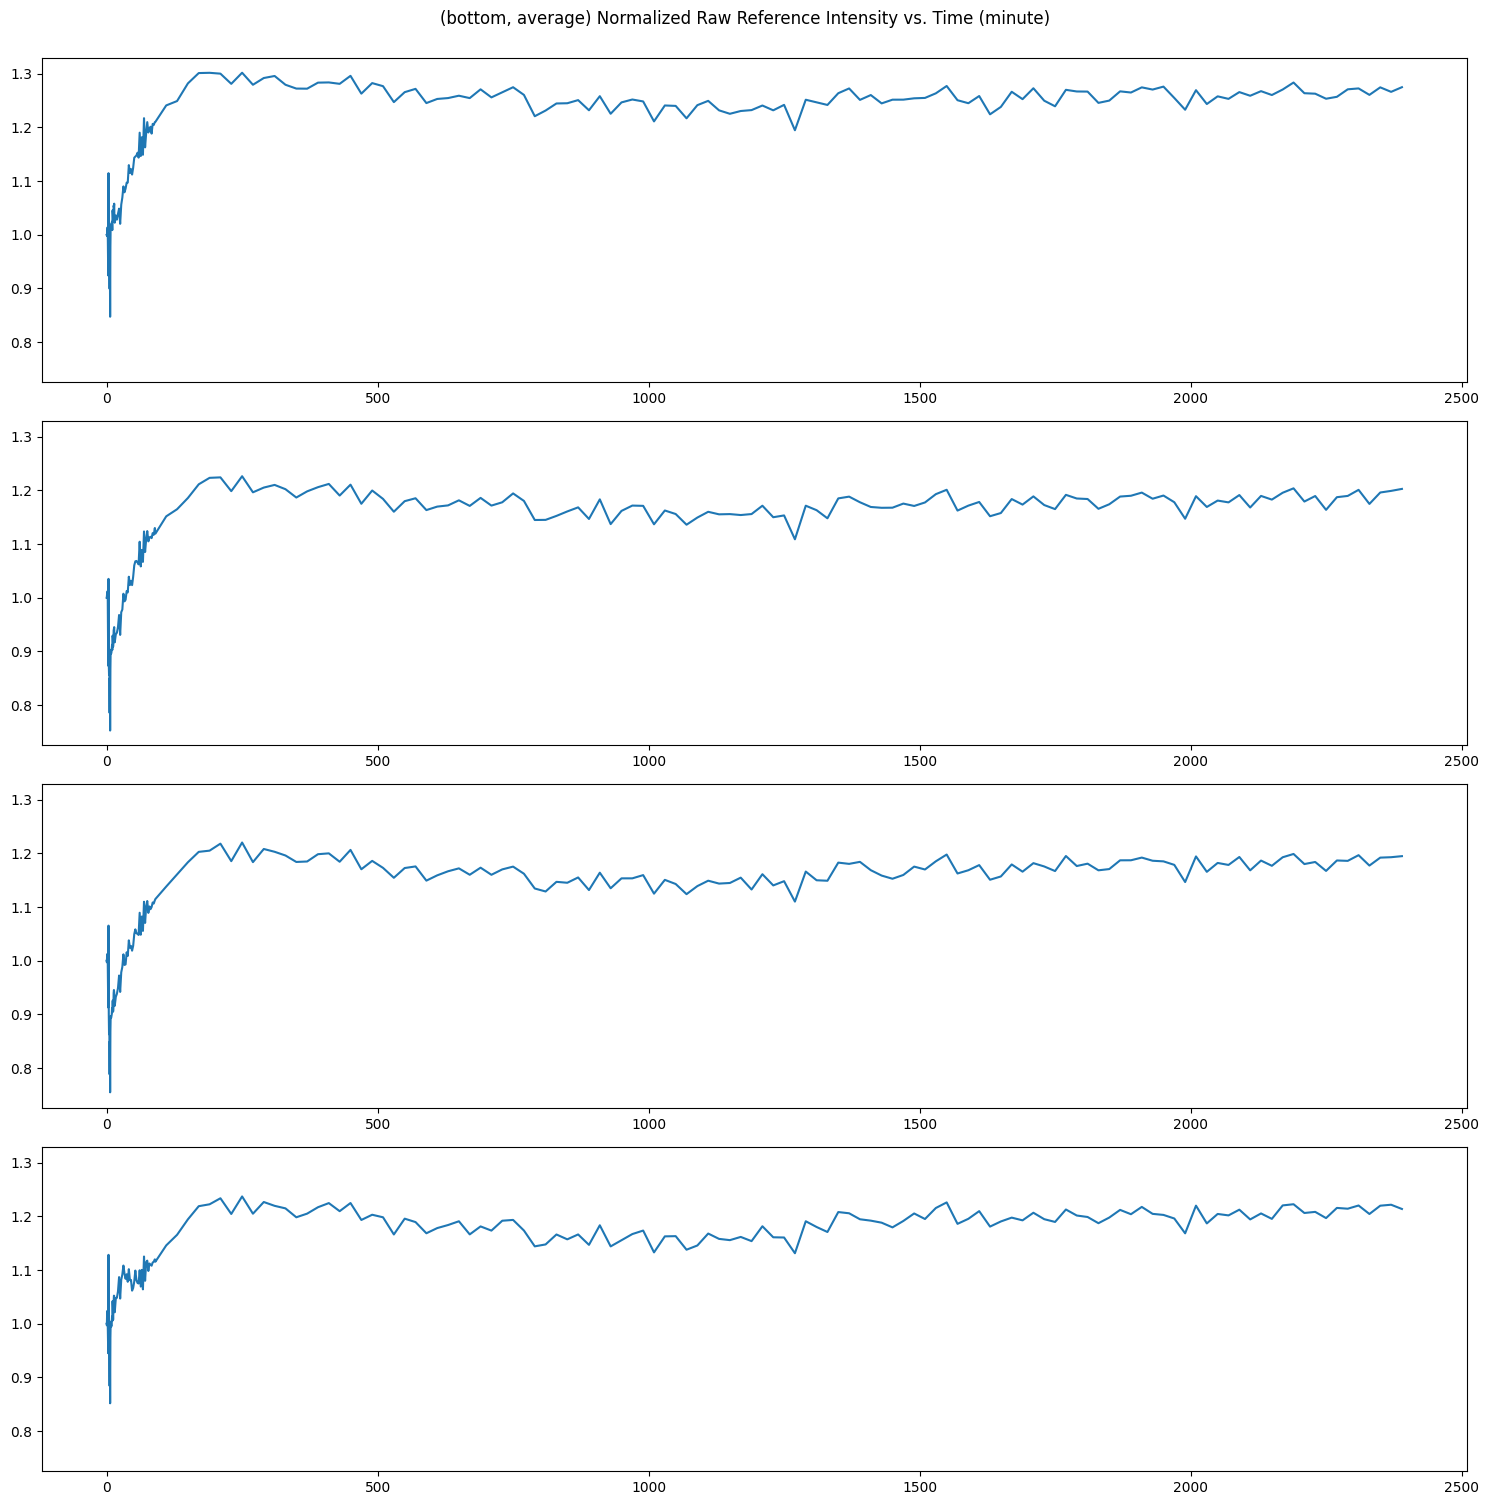

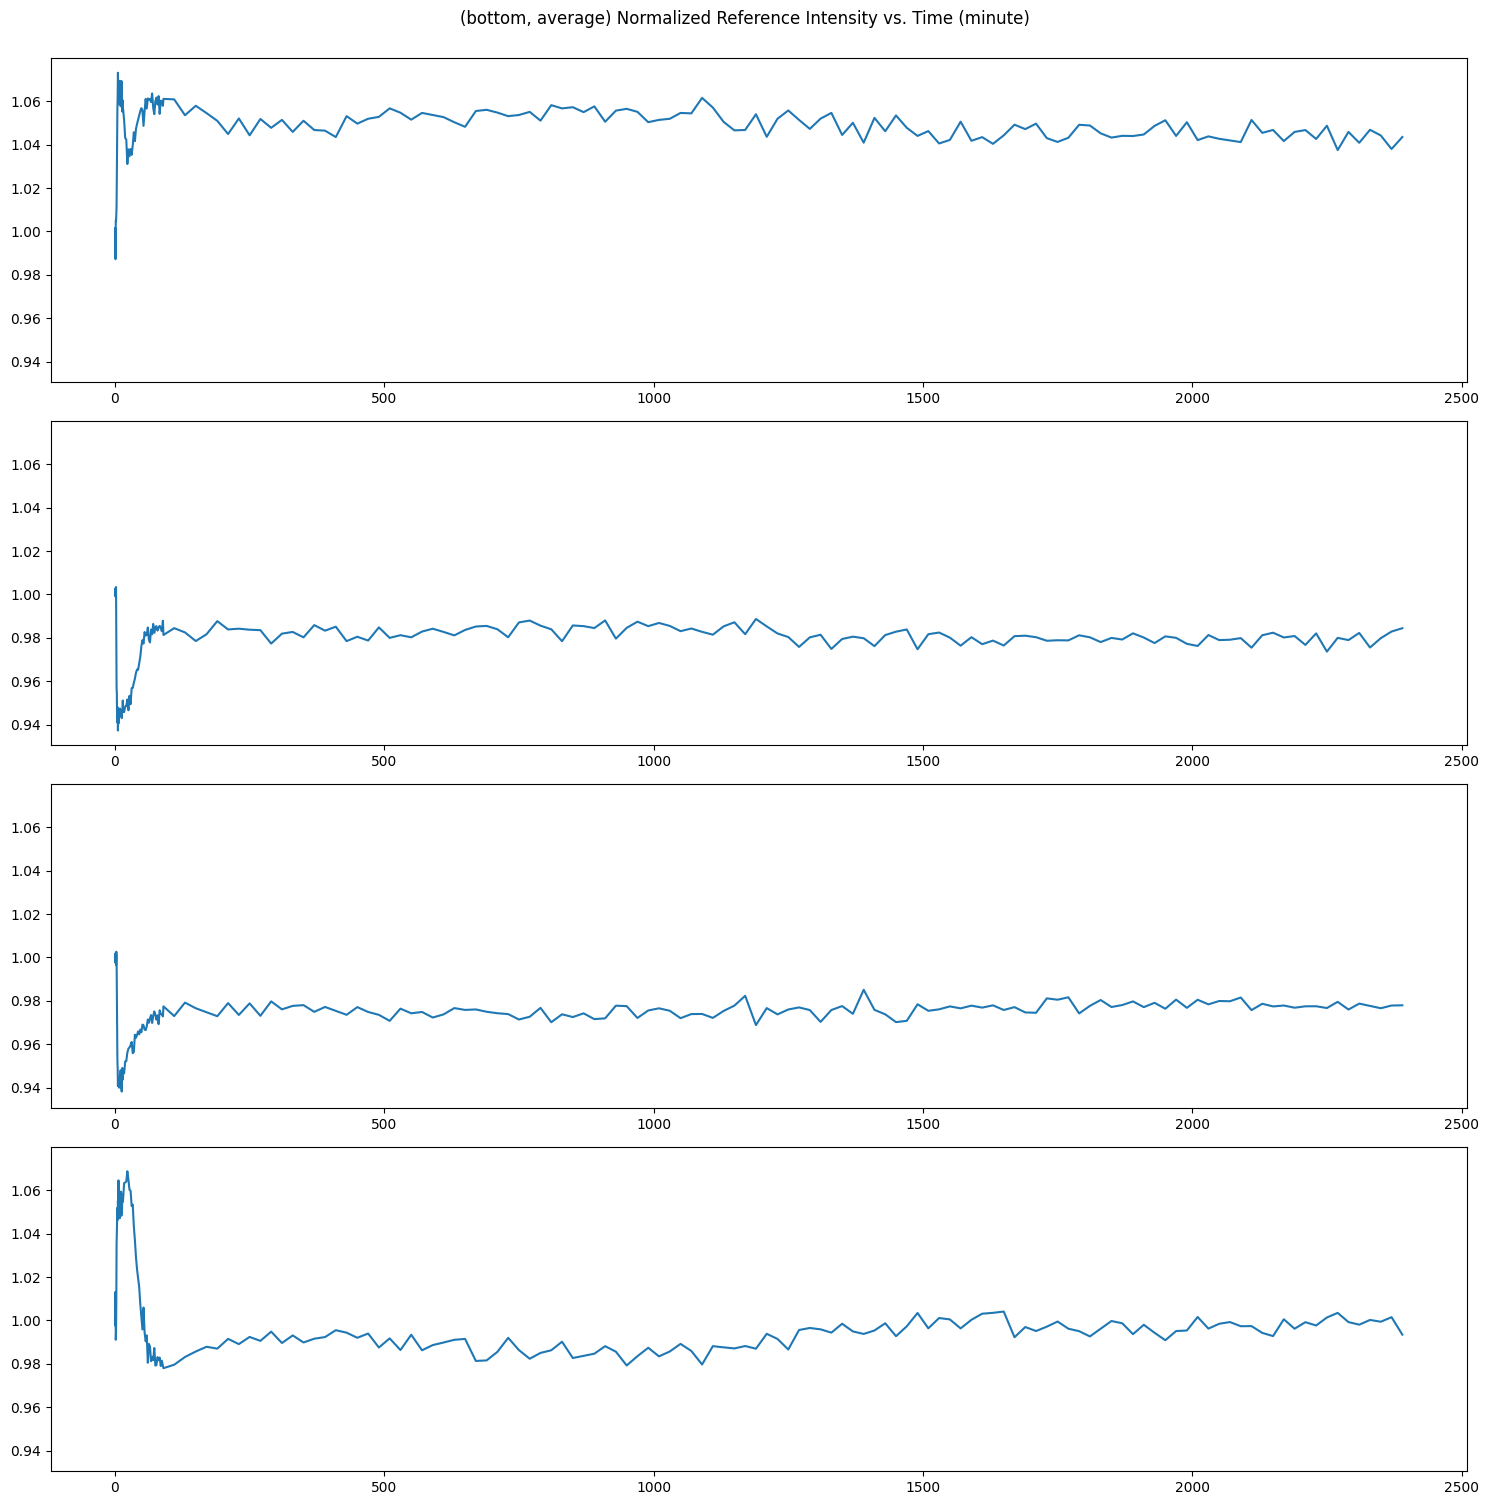

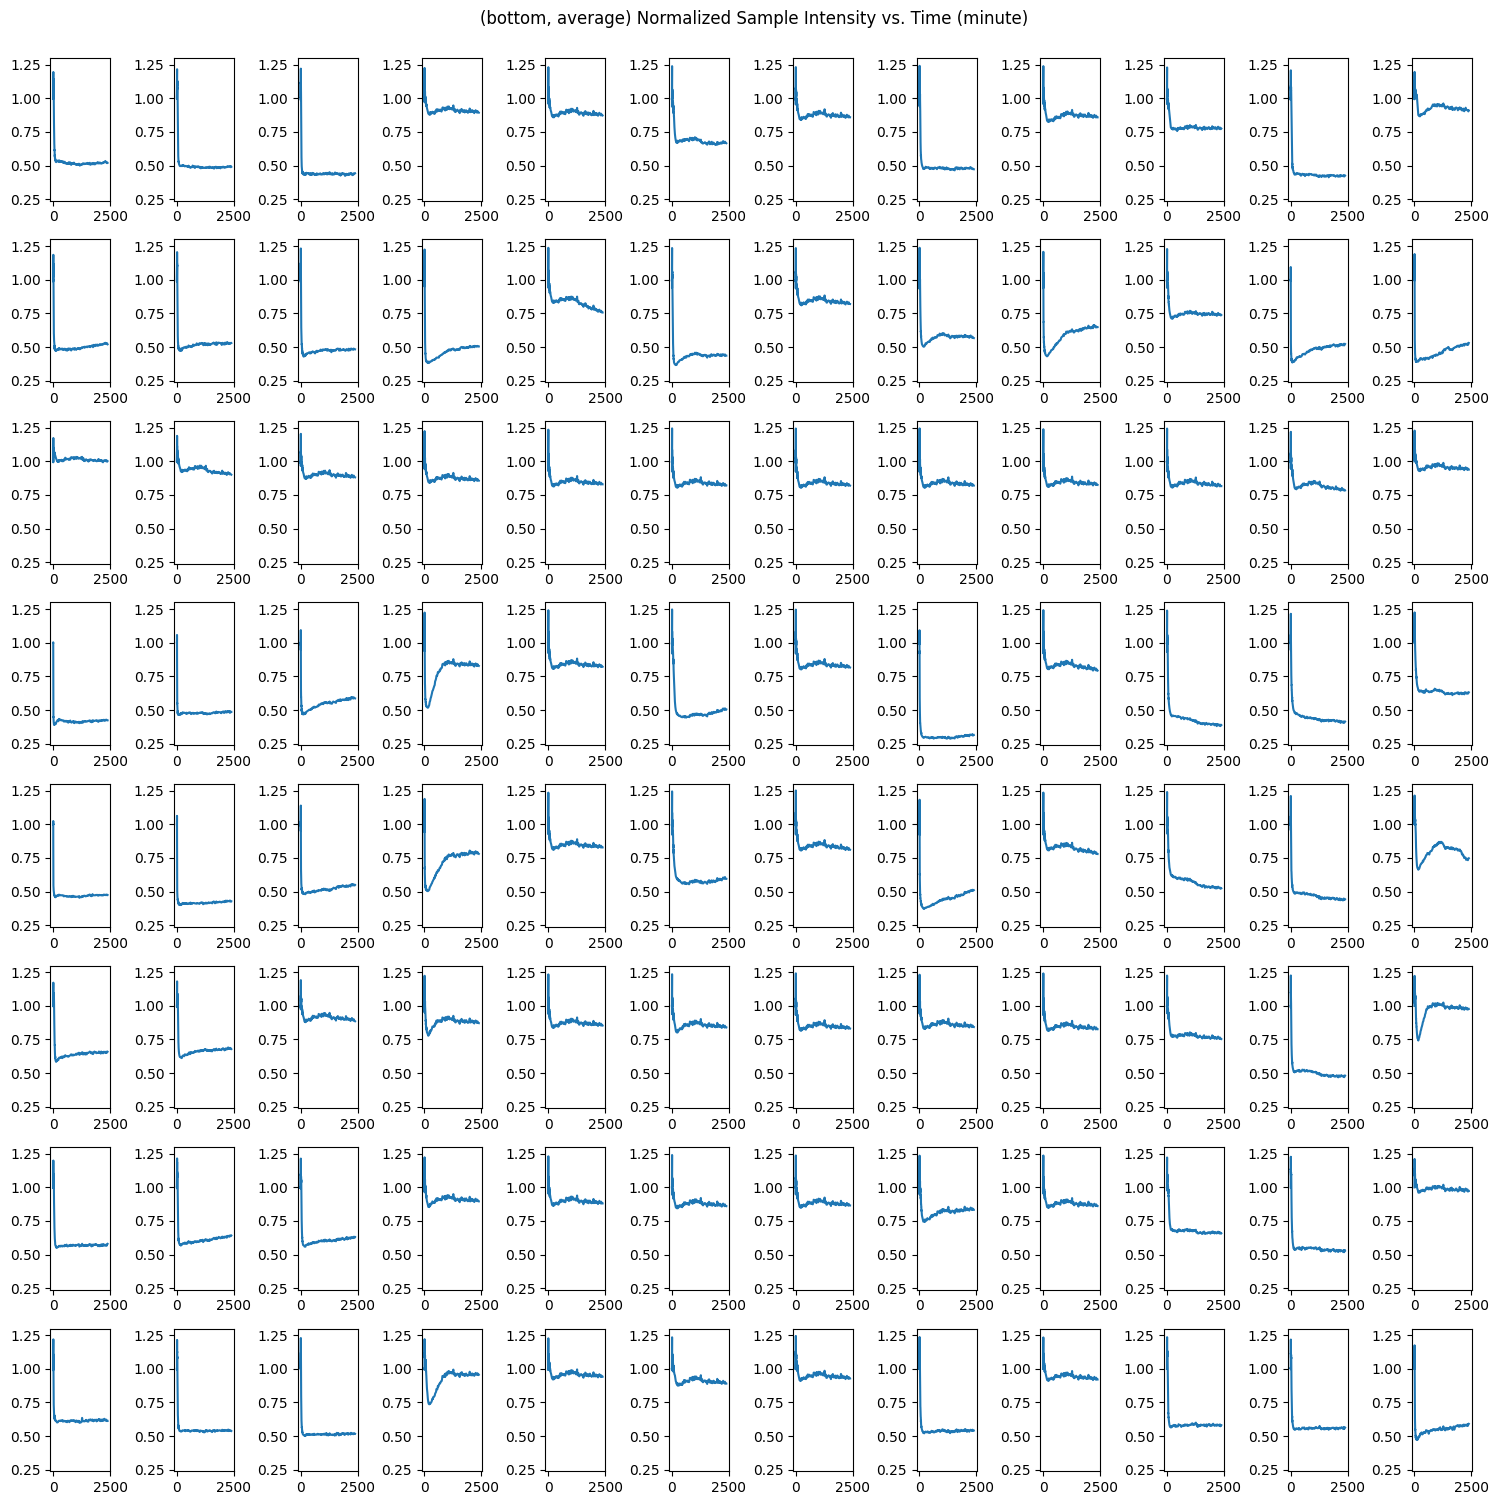

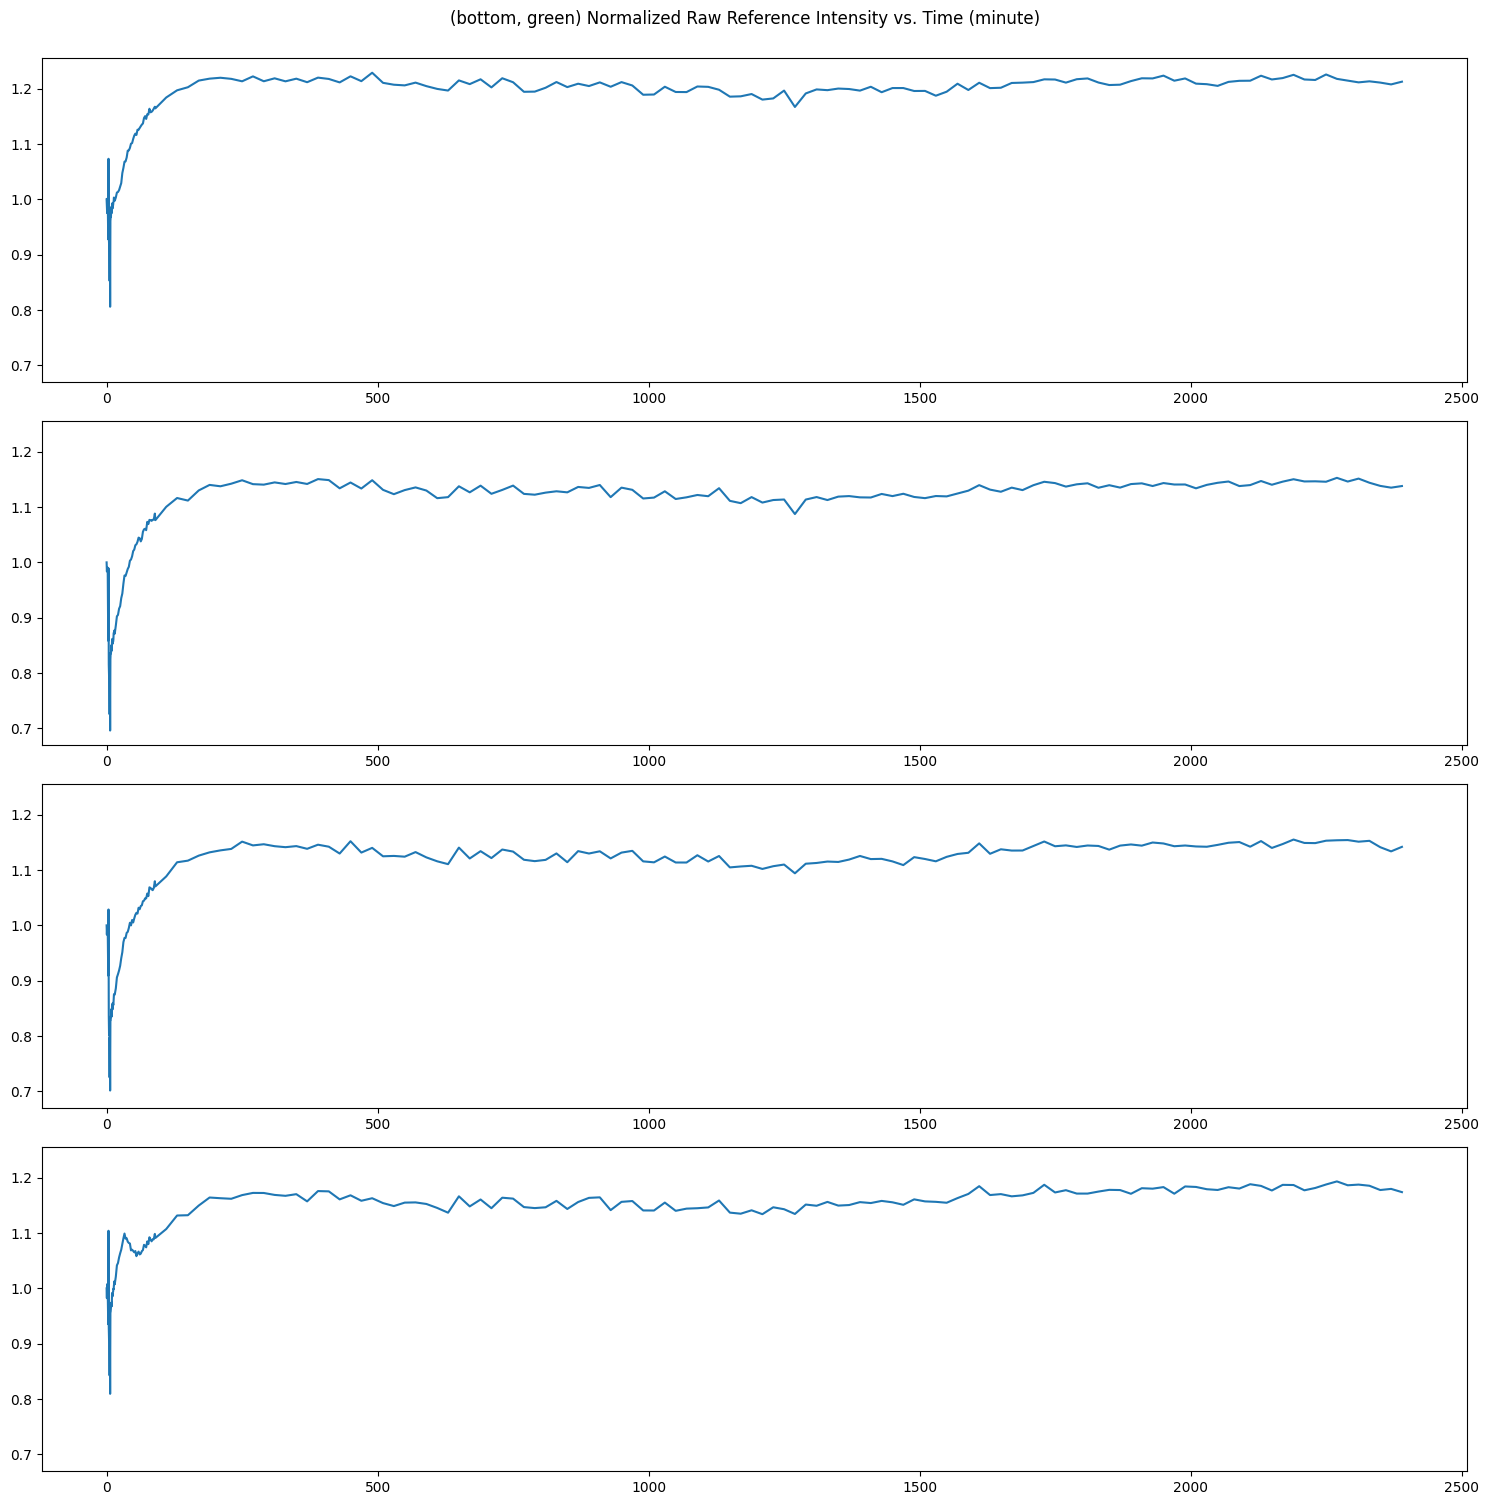

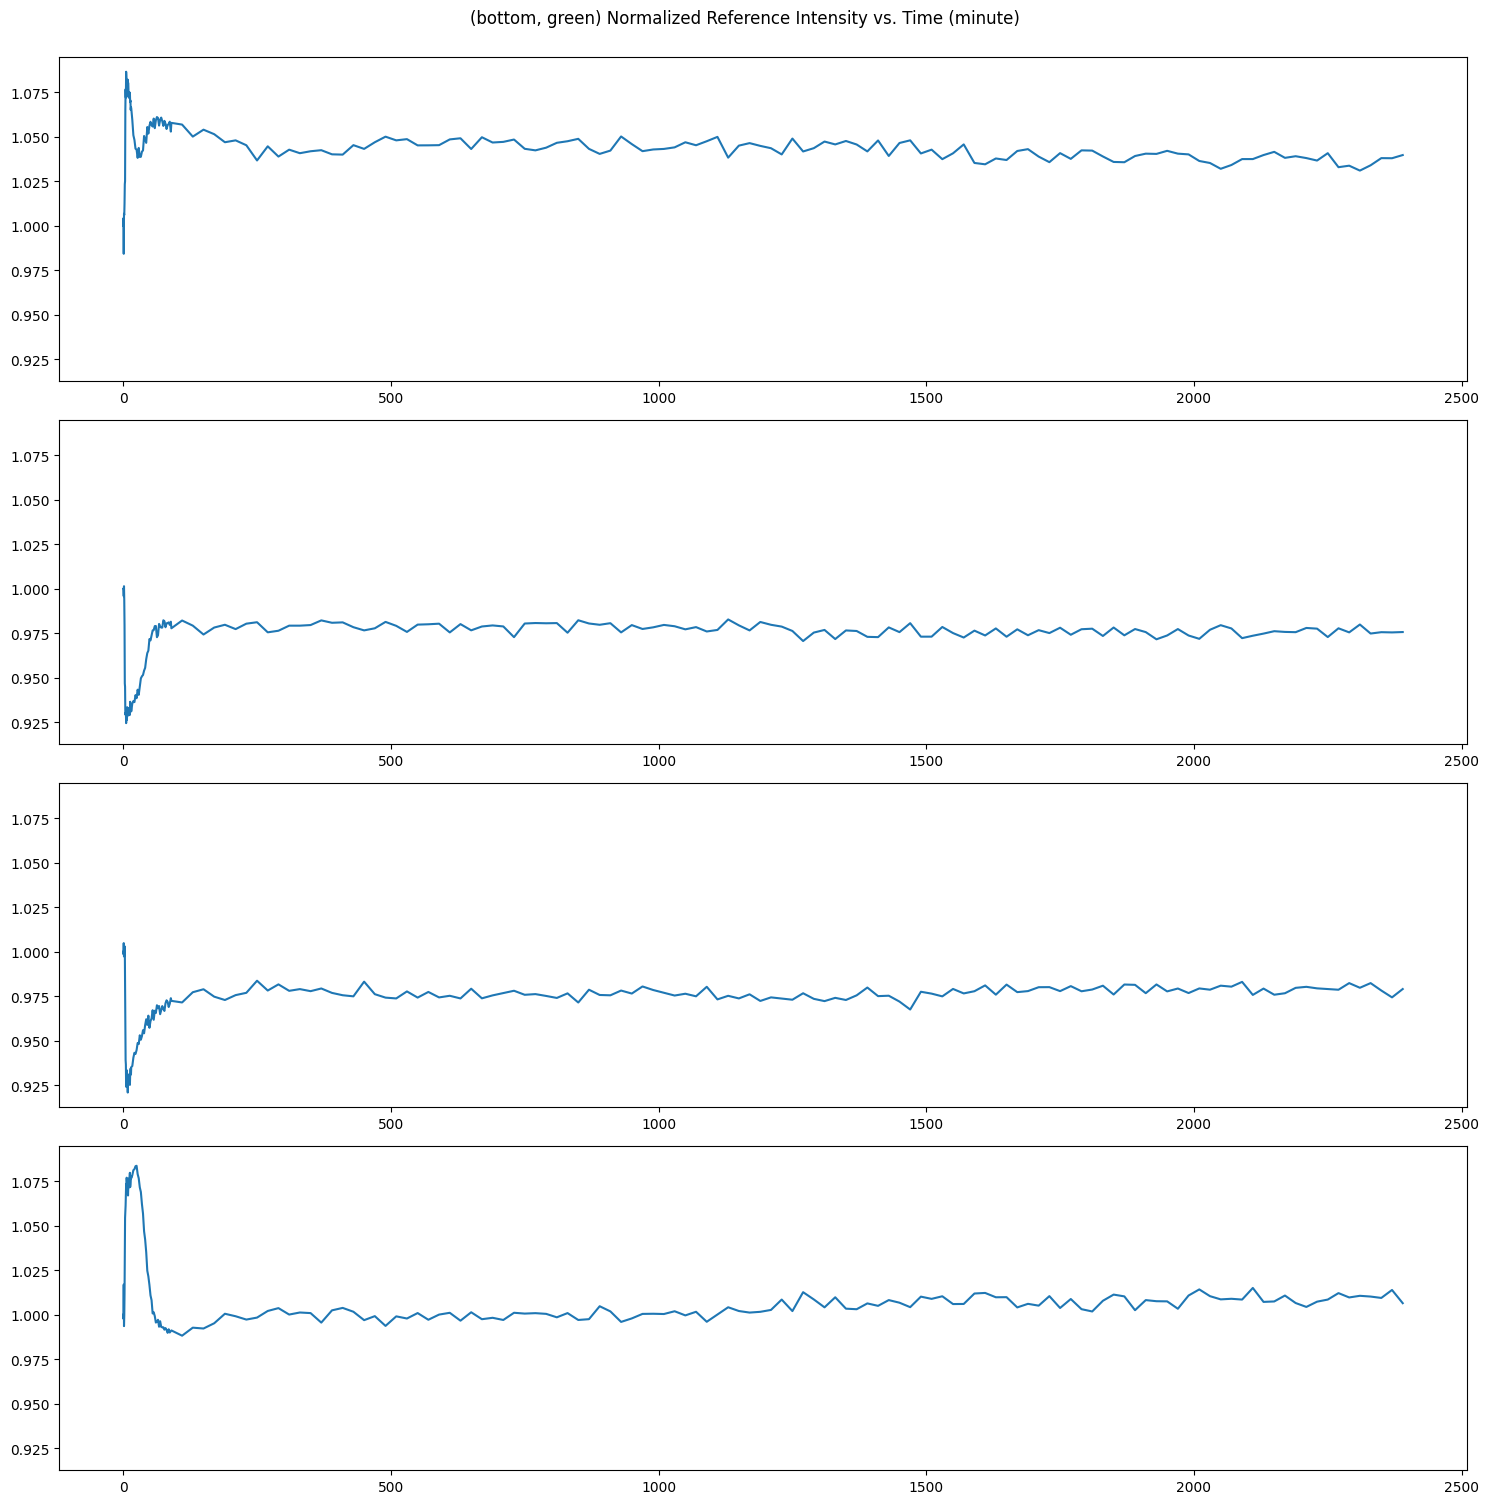

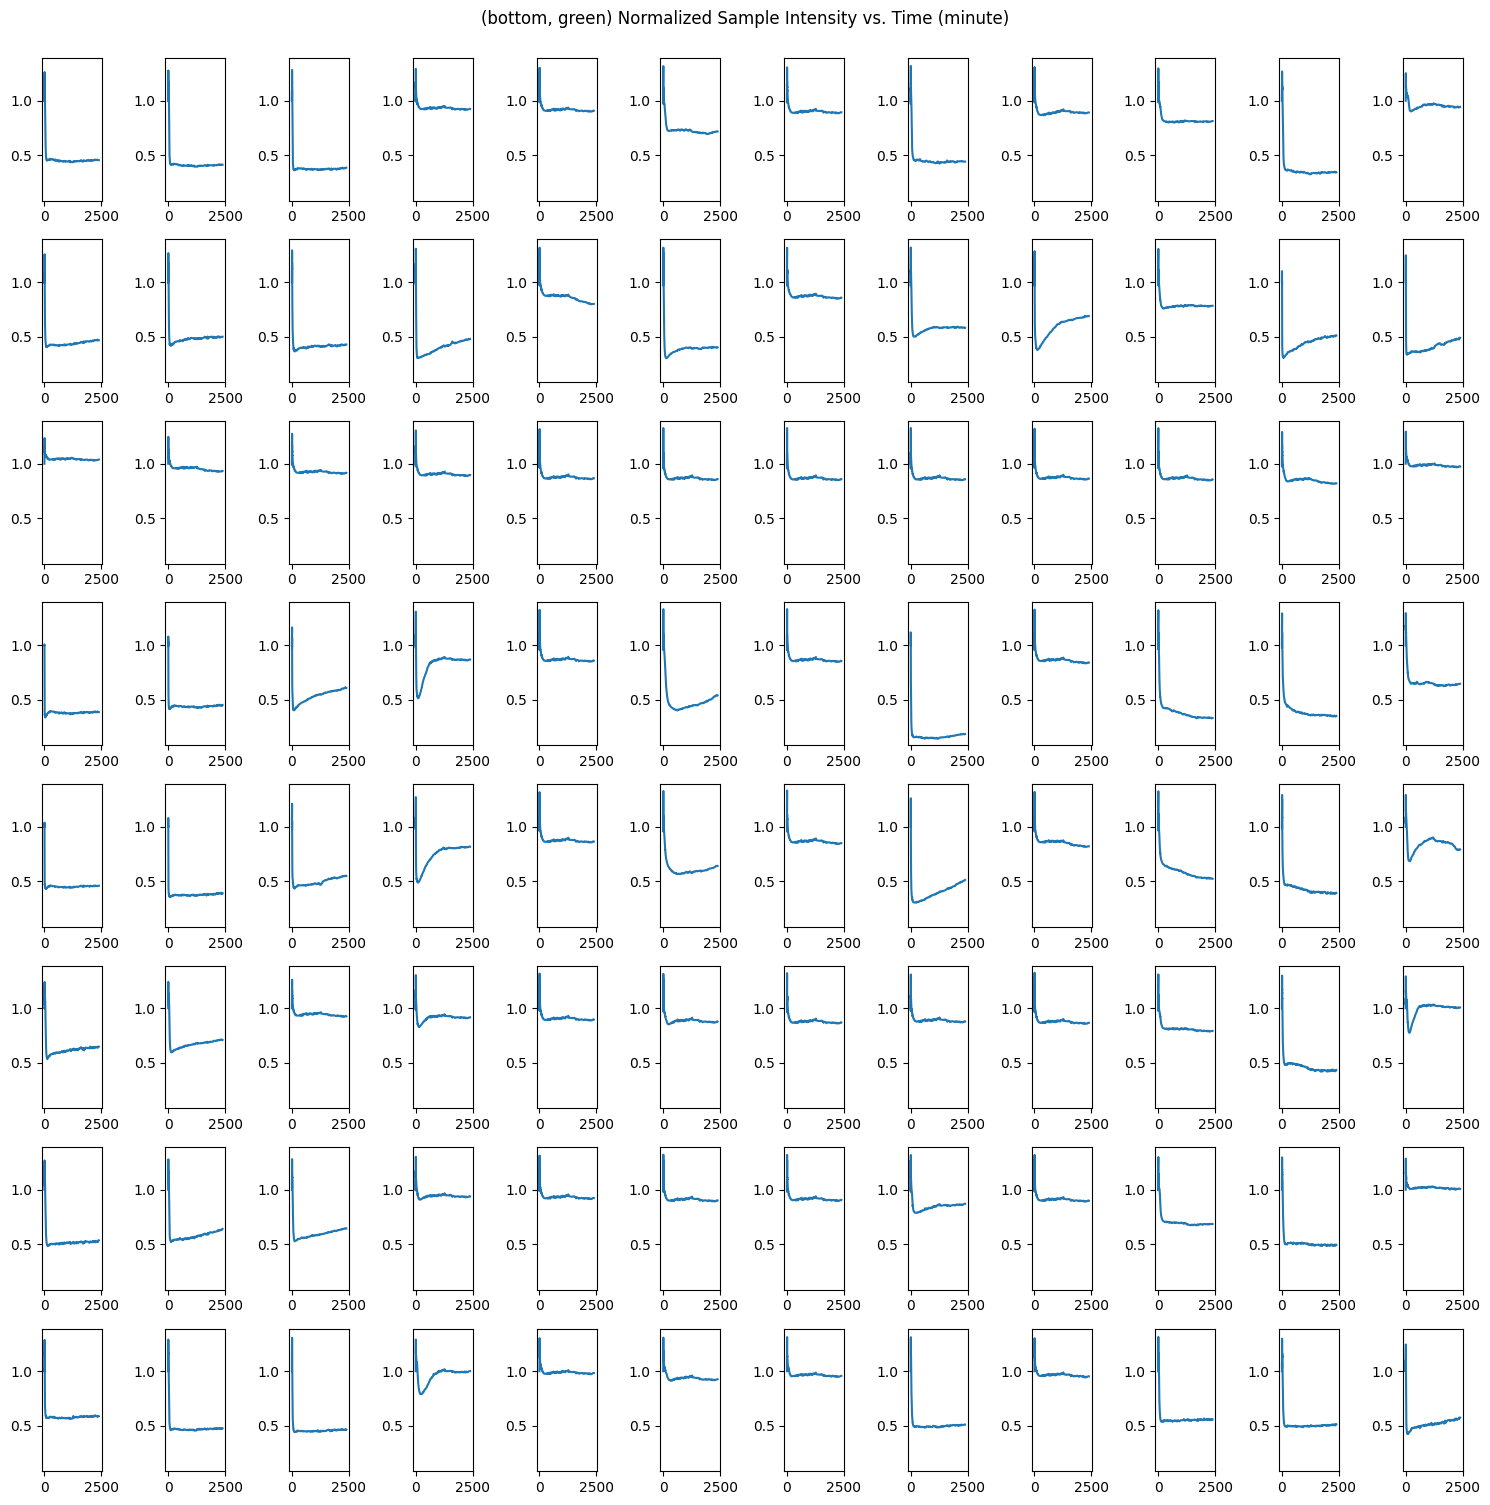

In [9]:
# Display the data computed from the intensities.
experiment.display_post_processed_data()

## Export Results

In [10]:
# Export the data to CSVs.
experiment.export_post_processed_data()